# 01 - Data Extraction

---

## Pipeline Stage 1 / 5

This notebook covers the first step of the project: extracting raw data from external sources.

**Data Sources:**
- OECD Country Risk Ratings (PDF documents)
- World Bank World Development Indicators (API)

---

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

In [3]:
from src.utils import config, io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standard plotting configuration
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (9, 5),
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10
})
sns.set_style('whitegrid')

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


# 2 - Data Extraction

## 2.1 - OECD Rating

In [4]:
from src.extraction import build_oecd_dataset

In [5]:
pdf_fname = '03-07-2026' # Previous: '02-02-2024'
oecd_rating_matrix_previous = build_oecd_dataset.get_clean_oecd_rating_df(oecd_fname=pdf_fname) # 02-02-2024
oecd_rating_matrix_previous

Reading CSV


,1999-01-01,2000-01-01,2001-01-01,2002-01-01,2003-01-01,2004-01-01,2005-01-01,2006-01-01,2007-01-01,2008-01-01,...,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01,2025-01-01,2026-01-01
ISO3_COUNTRY_CODE,,,,,,,,,,,,,,,,,,,,,
AFG,7,7,-,-,-,-,-,-,-,7,...,7,7,7,7,7,7,7,7,7,7
ALB,7,7,7,7,7,7,6,6,6,6,...,6,6,6,5,5,5,5,5,5,4
DZA,6,6,5,5,4,4,4,3,3,3,...,4,4,4,5,5,5,5,5,5,5
AND,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
AGO,7,7,7,7,7,7,7,7,7,7,...,6,6,6,6,6,6,6,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,6,6,6,6,5,5,5,5,5,4,...,5,5,5,4,4,4,4,4,4,4
PSE,-,-,-,-,-,-,-,-,-,-,...,7,7,7,7,7,7,7,7,7,7
YEM,7,7,7,6,6,6,6,6,6,6,...,7,7,7,7,7,7,7,7,7,7


In [6]:
import numpy as np
oecd_rating_matrix_previous.replace('-', np.nan).isna().sum().sum()

np.int64(909)

In [7]:
oecd_rating_matrix = build_oecd_dataset.get_clean_oecd_rating_df(oecd_fname='03-07-2026') # 02-02-2024
oecd_rating_matrix

Reading CSV


,1999-01-01,2000-01-01,2001-01-01,2002-01-01,2003-01-01,2004-01-01,2005-01-01,2006-01-01,2007-01-01,2008-01-01,...,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01,2025-01-01,2026-01-01
ISO3_COUNTRY_CODE,,,,,,,,,,,,,,,,,,,,,
AFG,7,7,-,-,-,-,-,-,-,7,...,7,7,7,7,7,7,7,7,7,7
ALB,7,7,7,7,7,7,6,6,6,6,...,6,6,6,5,5,5,5,5,5,4
DZA,6,6,5,5,4,4,4,3,3,3,...,4,4,4,5,5,5,5,5,5,5
AND,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
AGO,7,7,7,7,7,7,7,7,7,7,...,6,6,6,6,6,6,6,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,6,6,6,6,5,5,5,5,5,4,...,5,5,5,4,4,4,4,4,4,4
PSE,-,-,-,-,-,-,-,-,-,-,...,7,7,7,7,7,7,7,7,7,7
YEM,7,7,7,6,6,6,6,6,6,6,...,7,7,7,7,7,7,7,7,7,7


In [8]:
import numpy as np
oecd_rating_matrix.replace('-', np.nan).isna().sum().sum()

np.int64(909)

In [10]:
io.save_csv(oecd_rating_matrix, config.INTERIM_DATA_DIR / 'oecd_rating_matrix.csv', index=True)

## 2.2 - World Bank Features

In [11]:
from src.extraction import world_bank, world_bank_WDI_indicators

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [12]:
oecd_rating_matrix = io.load_csv(config.INTERIM_DATA_DIR / 'oecd_rating_matrix.csv', index_col=0)
oecd_countries = list(oecd_rating_matrix.index)
min_year = int(min(oecd_rating_matrix.columns)[:4])
max_year = int(max(oecd_rating_matrix.columns)[:4])

In [149]:
wb_df = world_bank.get_world_bank_indicators(
    indicators=world_bank_WDI_indicators.WORLD_BANK_INDICATORS,
    countries=oecd_countries,
    start_year=min_year,
    end_year=max_year,
)
wb_df

Capping end year to 2025 (WB data not yet available beyond that)
[1/74] GDP (current US$) (NY.GDP.MKTP.CD) (fetching…)
[2/74] GDP growth (annual %) (NY.GDP.MKTP.KD.ZG) (fetching…)
[3/74] GDP, PPP (current international $) (NY.GDP.MKTP.PP.CD) (fetching…)
[4/74] GDP per capita (current US$) (NY.GDP.PCAP.CD) (fetching…)
[5/74] GDP per capita growth (annual %) (NY.GDP.PCAP.KD.ZG) (fetching…)
[6/74] Gross capital formation (annual % growth) (NE.GDI.TOTL.KD.ZG) (fetching…)
[7/74] Gross capital formation (% of GDP) (NE.GDI.TOTL.ZS) (fetching…)
[8/74] Industry (including construction), value added (current US$) (NV.IND.TOTL.CD) (fetching…)
[9/74] Industry (including construction), value added (annual % growth) (NV.IND.TOTL.KD.ZG) (fetching…)
[10/74] Industry (including construction), value added (% of GDP) (NV.IND.TOTL.ZS) (fetching…)
[11/74] Employment in industry (% of total employment) (modeled ILO estimate) (SL.IND.EMPL.ZS) (fetching…)
[12/74] Services, value added (current US$) (NV.SRV.TO

,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,NE.GDI.TOTL.KD.ZG,NE.GDI.TOTL.ZS,NV.IND.TOTL.CD,NV.IND.TOTL.KD.ZG,NV.IND.TOTL.ZS,...,SP.POP.GROW,SP.URB.TOTL.IN.ZS,EN.POP.DNST,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,IQ.CPA.BREG.XQ,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
ABW-1999,1.722905e+09,1.238042,2.489441e+09,19216.197235,-0.125966,NaN,30.869001,2.678827e+08,NaN,15.548314,...,1.356486,65.361486,498.105556,NaN,43.669781,NaN,NaN,NaN,44.620525,44.620525
AFG-1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.728116,18.390327,30.491981,NaN,108.686031,46.609,NaN,NaN,NaN,NaN
AGO-1999,6.152923e+09,2.181490,5.669622e+10,392.725539,-1.130799,NaN,NaN,NaN,NaN,NaN,...,3.295277,49.259527,12.566965,NaN,93.586677,77.380,NaN,NaN,NaN,2.573386
ALB-1999,3.283942e+09,12.250728,1.103390e+10,1056.344812,12.963927,31.19083,24.271511,6.082915e+08,20.139252,18.523214,...,-0.633352,40.897284,113.459051,NaN,59.064263,62.061,NaN,NaN,NaN,4.116988
AND-1999,1.240295e+09,4.099079,2.075776e+09,18875.288370,3.579455,NaN,NaN,NaN,NaN,NaN,...,0.500413,92.540282,139.808511,NaN,37.399632,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,42.534,NaN,NaN,NaN,NaN
YEM-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33.103,NaN,NaN,NaN,NaN
ZAF-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,55.584,NaN,NaN,NaN,NaN


In [151]:
io.save_csv(wb_df, config.INTERIM_DATA_DIR / 'worldbank_dataset_extracted.csv', index=True)

## 3 - Extracted Data Overview

In [21]:
oecd_rating_matrix = io.load_csv(config.INTERIM_DATA_DIR / 'oecd_rating_matrix.csv', index_col=0)
wb_df = io.load_csv(config.INTERIM_DATA_DIR / 'worldbank_dataset_extracted.csv', index_col=0)
oecd_rating_matrix.shape, wb_df.shape

((201, 28), (5373, 74))

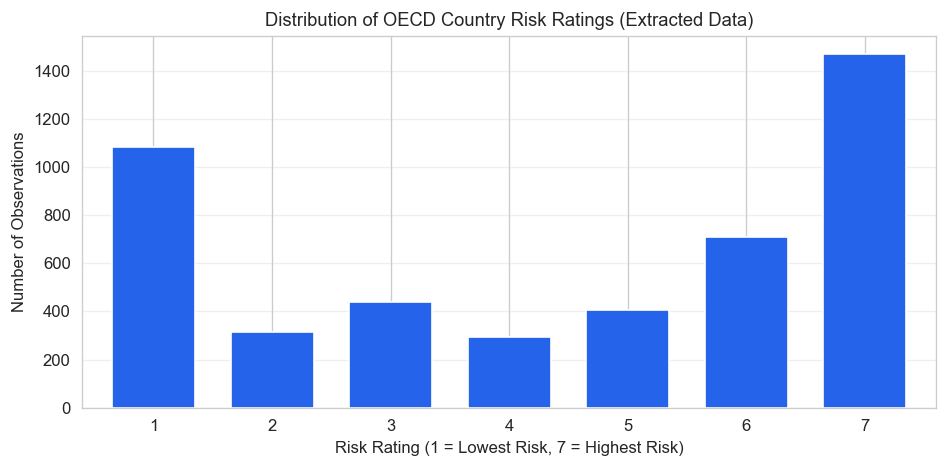

In [ ]:
# OECD Rating Distribution
rating_values = oecd_rating_matrix.replace('-', np.nan).stack()
rating_counts = rating_values.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
rating_counts.plot(kind='bar', ax=ax, color='#2563eb', width=0.7)
ax.set_title('Distribution of OECD Country Risk Ratings (Extracted Data)')
ax.set_xlabel('Risk Rating (1 = Lowest Risk, 7 = Highest Risk)')
ax.set_ylabel('Number of Observations')
ax.set_xticklabels(rating_counts.index, rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports/plots' / 'oecd_rating_distribution.png', bbox_inches='tight')
plt.show()

In [44]:
# World Bank Data Overview
n_countries = len(wb_df.reset_index().iloc[:, 0].str.split('-', expand=True)[0].unique())
n_years = len(wb_df.reset_index().iloc[:, 0].str.split('-', expand=True)[1].unique())
n_features = len(wb_df.columns)

print(f"World Bank Dataset Summary:")
print(f"  Countries: {n_countries}")
print(f"  Time period: {wb_df.reset_index().iloc[:, 0].str.split('-', expand=True)[1].min()} - {wb_df.reset_index().iloc[:, 0].str.split('-', expand=True)[1].max()}")
print(f"  Features: {n_features}")
print(f"  Total observations: {len(wb_df)}")
print(f"  Overall missingness: {wb_df.isna().mean().mean():.1%}")

World Bank Dataset Summary:
  Countries: 199
  Time period: 1999 - 2025
  Features: 76
  Total observations: 5373
  Overall missingness: 27.3%
